In [17]:
import sys
sys.path.append(r"C:\Users\nigel\Desktop\prax\robust-anomaly-cifar10")

import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

from src.dataset import CorruptedCIFAR10
from src.models import ConvAutoencoder
from src.train_ae import train_autoencoder
from src.evaluate_ae import reconstruction_scores, compute_auroc


In [2]:
transform = transforms.Compose([transforms.ToTensor()])

full_train = CorruptedCIFAR10(
    root=r"C:\Users\nigel\Desktop\prax\robust-anomaly-cifar10\data\raw",
    train=True,
    download=True,
    transform=transform,
    corruption_type=None  # CLEAN
)

train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size
train_ds, val_ds = random_split(full_train, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)

print(len(train_ds), len(val_ds))


45000 5000


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = ConvAutoencoder(latent_dim=128)

model, history = train_autoencoder(
    model,
    train_loader,
    val_loader=val_loader,
    epochs=10,
    lr=1e-3,
    device=device
)


Using device: cpu


Epoch 1/10: 100%|████████████████████████████████████████████████████████████████████| 352/352 [01:09<00:00,  5.09it/s]


Epoch 1: Train Loss = 0.025712 | Val Loss = 0.015123


Epoch 2/10: 100%|████████████████████████████████████████████████████████████████████| 352/352 [01:08<00:00,  5.10it/s]


Epoch 2: Train Loss = 0.012883 | Val Loss = 0.011082


...

Epoch 8: Train Loss = 0.006356 | Val Loss = 0.006285


Epoch 9/10: 100%|████████████████████████████████████████████████████████████████████| 352/352 [01:09<00:00,  5.10it/s]


Epoch 9: Train Loss = 0.006009 | Val Loss = 0.005791


Epoch 10/10: 100%|███████████████████████████████████████████████████████████████████| 352/352 [01:08<00:00,  5.11it/s]


Epoch 10: Train Loss = 0.005751 | Val Loss = 0.005679


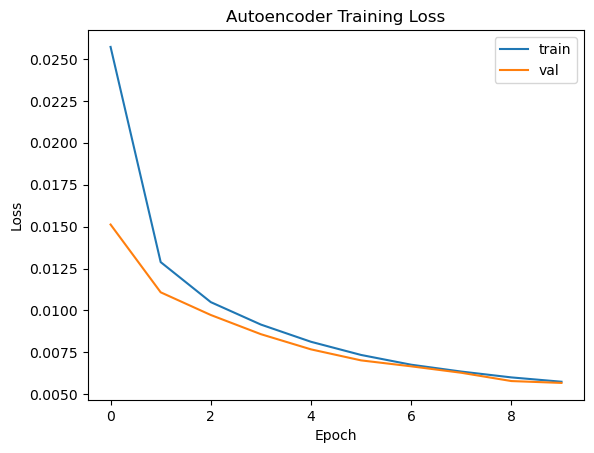

In [4]:
plt.plot(history["train_loss"], label="train")
if len(history["val_loss"]) > 0:
    plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Autoencoder Training Loss")
plt.show()


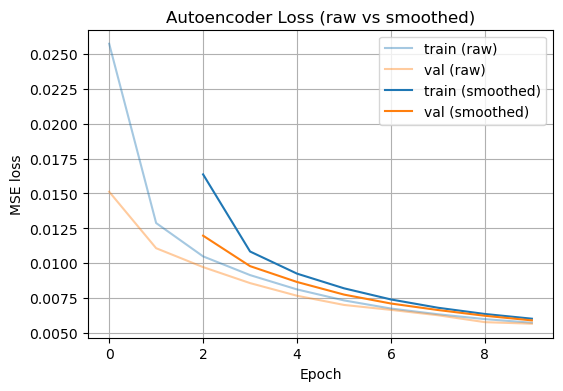

In [10]:
# Smoothed loss curves
def moving_average(x, window=3):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

train_loss = history["train_loss"]
val_loss = history["val_loss"]

plt.figure(figsize=(6,4))
plt.plot(train_loss, label="train (raw)", alpha=0.4)
if len(val_loss) > 0:
    plt.plot(val_loss, label="val (raw)", alpha=0.4)

ma_train = moving_average(train_loss, window=3)
plt.plot(range(2, 2+len(ma_train)), ma_train, label="train (smoothed)", color="C0")
if len(val_loss) > 0:
    ma_val = moving_average(val_loss, window=3)
    plt.plot(range(2, 2+len(ma_val)), ma_val, label="val (smoothed)", color="C1")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Autoencoder Loss (raw vs smoothed)")
plt.legend()
plt.grid(True)
plt.show()


This shows raw loss per epoch plus a smoothed moving average so that we can see more clearly about convergence and overfitting tendencies

In [5]:
clean_test = CorruptedCIFAR10(
    root=r"C:\Users\nigel\Desktop\prax\robust-anomaly-cifar10\data\raw",
    train=False,
    download=True,
    transform=transform,
    corruption_type=None
)

corrupted_test = CorruptedCIFAR10(
    root=r"C:\Users\nigel\Desktop\prax\robust-anomaly-cifar10\data\raw",
    train=False,
    download=True,
    transform=transform,
    corruption_type="gaussian_noise",
    severity=3,
    corruption_prob=1.0
)

clean_loader = DataLoader(clean_test, batch_size=128, shuffle=False)
corr_loader = DataLoader(corrupted_test, batch_size=128, shuffle=False)

clean_scores = reconstruction_scores(model, clean_loader, device=device)
anomaly_scores = reconstruction_scores(model, corr_loader, device=device)

auroc = compute_auroc(clean_scores, anomaly_scores)
print("AUROC (clean vs corrupted):", auroc)


AUROC (clean vs corrupted): 0.93264652


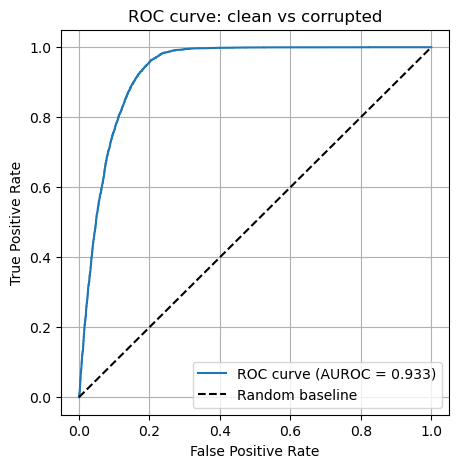

In [18]:
# ROC curve for clean vs corrupted
y_true = np.concatenate([
    np.zeros_like(clean_scores),      # 0 = clean (negative class)
    np.ones_like(anomaly_scores)      # 1 = corrupted (positive class)
])
y_scores = np.concatenate([clean_scores, anomaly_scores])

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUROC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve: clean vs corrupted")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


The ROC curve visually compares autoencoder-based detector against random guessing. 

The closer the curve is to the top-left, the better as illustrated.

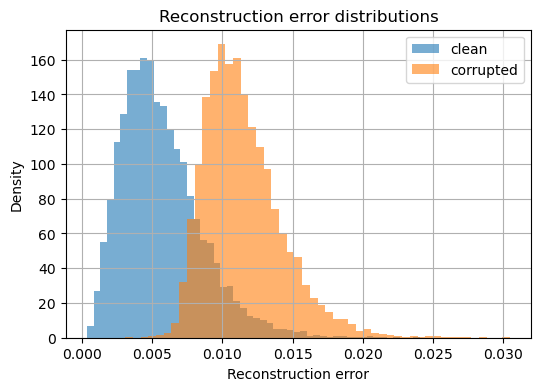

In [12]:
# Reconstruction score distributions
plt.figure(figsize=(6,4))
plt.hist(clean_scores, bins=50, alpha=0.6, label="clean", density=True)
plt.hist(anomaly_scores, bins=50, alpha=0.6, label="corrupted", density=True)
plt.xlabel("Reconstruction error")
plt.ylabel("Density")
plt.title("Reconstruction error distributions")
plt.legend()
plt.grid(True)
plt.show()


This shows how well reconstruction error separates clean from corrupted images.

Good separation (different peaks, little overlap) explains why AUROC is high.

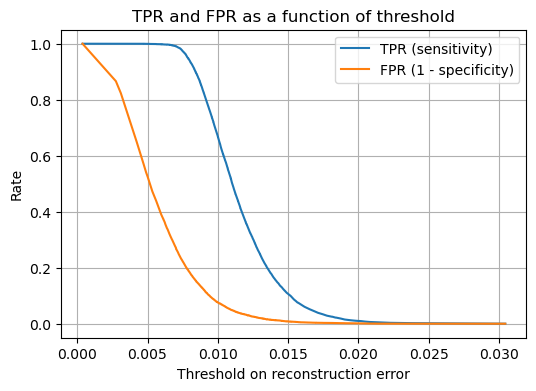

In [16]:
# True Positive Rate (TPR) / False Positive Rate (FPR) vs threshold
plt.figure(figsize=(6,4))
plt.plot(thresholds, tpr, label="TPR (sensitivity)")
plt.plot(thresholds, fpr, label="FPR (1 - specificity)")
plt.xlabel("Threshold on reconstruction error")
plt.ylabel("Rate")
plt.title("TPR and FPR as a function of threshold")
plt.legend()
plt.grid(True)
plt.show()


 This illustrates how choosing different thresholds on reconstruction error trades off between detecting more anomalies (higher TPR) and raising more false alarms (higher FPR)

In [6]:
import os

# change working directory to your project folder
os.chdir(r"C:\Users\nigel\Desktop\prax\robust-anomaly-cifar10")
print("Current working directory:", os.getcwd())

# create results folder if missing
os.makedirs("results", exist_ok=True)


Current working directory: C:\Users\nigel\Desktop\prax\robust-anomaly-cifar10


In [7]:
import os

os.makedirs("results", exist_ok=True)
print("results/ folder ready")


results/ folder ready


In [8]:
import torch
torch.save(model.state_dict(), "results/ae_baseline.pth")
print("Model saved to results/ae_baseline.pth")


Model saved to results/ae_baseline.pth
